# Value Profiles & Distributional Pluralism

Converts raw logistic-regression coefficients into softmax-normalised
value priority distributions (π_V = softmax(β / T)) with configurable
temperature *T*, then uses Jensen-Shannon divergence to quantify
within-group diversity for LLMs versus physicians.

In [96]:
DIR = "/Users/payalchandak/Desktop/HVP Preprint/ValueBench"
import os
os.chdir(DIR)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300      

from src.analysis import (
    load_all_decisions,
    HUMAN_CONSENSUS,
    value_weights,
    softmax_profile,
    consensus_profile_from_subset,
    pairwise_jsd_matrix,
    lrt_uniform_null,
    bootstrap_mean_jsd,
    permutation_test_jsd,
)
from src.response_models.case import VALUE_NAMES
from collections import defaultdict
from scipy.spatial.distance import jensenshannon

from pathlib import Path
LLM_DIR = Path(DIR) / "data" / "llm_decisions" / "physician_recommendation"

MODEL_DISPLAY_NAMES = {
    'anthropic/claude-opus-4.5': 'Claude Opus 4.5',
    'deepseek/deepseek-chat': 'DeepSeek Chat',
    'google/gemini-3-pro-preview': 'Gemini 3 Pro',
    'meta-llama/llama-4-maverick': 'Meta Llama 4 Maverick',
    'mistralai/mistral-large-2512': 'Mistral AI Large',
    'moonshotai/kimi-k2-thinking': 'Moonshot AI Kimi K2',
    'openai/gpt-5.2': 'OpenAI GPT 5.2',
    'perplexity/sonar-pro': 'Perplexity Sonar Pro',
    'qwen/qwen3-max': 'Qwen 3 Max',
    'x-ai/grok-4': 'X-AI Grok 4',
    'baidu/ernie-4.5-vl-424b-a47b': 'Baidu Ernie 4.5 VL',
    'z-ai/glm-4.6': 'Zhipu AI GLM 4.6',
    'human_consensus': 'Physician Consensus',
}

def get_display_name(model_id):
    if model_id in MODEL_DISPLAY_NAMES:
        return MODEL_DISPLAY_NAMES[model_id]
    if model_id.startswith("human/"):
        return "Physician " + model_id.split("/")[-1].split("_")[1][:4].upper()
    return model_id.split("/")[-1]

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.family"] = "sans-serif"

all_decisions = load_all_decisions(llm_dir=LLM_DIR)
decisions = [r for r in all_decisions if any(m.startswith("human/") for m in r.models)]

llm_models = sorted({m for r in decisions for m in r.models if not m.startswith("human/")})
human_participants = sorted({m for r in decisions for m in r.models if m.startswith("human/")})
all_decision_makers = llm_models + [HUMAN_CONSENSUS] + human_participants

print(f"Cases: {len(decisions)}")
print(f"LLMs: {len(llm_models)}  |  Human participants: {len(human_participants)}  |  Total decision makers: {len(all_decision_makers)}")

Cases: 50
LLMs: 12  |  Human participants: 20  |  Total decision makers: 33


In [97]:
TEMPERATURE = 0.262

## 1. Fit value weight profiles

Point-estimate logistic regression for every decision maker.

In [98]:
vw_results = {}
for model in all_decision_makers:
    try:
        vw_results[model] = value_weights(decisions, model)
    except ValueError as exc:
        print(f"  skip {get_display_name(model)}: {exc}")

print(f"Fitted {len(vw_results)} / {len(all_decision_makers)} decision makers")

Fitted 33 / 33 decision makers


## 2. Goodness of fit — McFadden pseudo-R²

Higher R² means the four-value model explains more of the
decision maker's choice variance than a null (intercept-free) model.

In [99]:
gof_rows = []
for model, res in vw_results.items():
    row = {"Decision Maker": get_display_name(model)}
    if res.glm_result is not None:
        try:
            row["McFadden R²"] = res.glm_result.pseudo_rsquared(kind="mcf")
        except Exception:
            row["McFadden R²"] = np.nan
        row["Deviance"] = res.glm_result.deviance
        row["Log-Lik"] = res.glm_result.llf
    else:
        row["McFadden R²"] = np.nan
        row["Deviance"] = np.nan
        row["Log-Lik"] = np.nan
    gof_rows.append(row)

gof_df = pd.DataFrame(gof_rows).sort_values("McFadden R²", ascending=False).reset_index(drop=True)
gof_df.style.format({"McFadden R²": "{:.4f}", "Deviance": "{:.2f}", "Log-Lik": "{:.2f}"}).background_gradient(
    subset=["McFadden R²"], cmap="YlGn"
)

,Decision Maker,McFadden R²,Deviance,Log-Lik
0,Mistral AI Large,0.3296,398.47,-224.49
1,Moonshot AI Kimi K2,0.3079,323.49,-220.57
2,Physician 0EFA,0.2631,51.02,-25.51
3,Qwen 3 Max,0.2605,414.75,-229.93
4,X-AI Grok 4,0.2574,383.74,-240.53
5,Baidu Ernie 4.5 VL,0.2573,328.39,-232.83
6,Gemini 3 Pro,0.2387,443.43,-251.80
7,Physician AAFB,0.2207,51.75,-25.88
8,Zhipu AI GLM 4.6,0.2155,286.31,-233.66
9,Physician D59B,0.2130,43.37,-21.69


## 3. Softmax normalisation

Transform raw β coefficients into a probability distribution π_V
over the four values using softmax(β / T).

In [100]:
profiles = {}
for model, res in vw_results.items():
    profiles[model] = softmax_profile(res.coefficients, temperature=TEMPERATURE)

profile_rows = []
for model, pi in profiles.items():
    row = {"Decision Maker": get_display_name(model)}
    row.update({v.capitalize(): f"{pi[v]:.3f}" for v in VALUE_NAMES})
    profile_rows.append(row)

profile_df = pd.DataFrame(profile_rows)
profile_df = profile_df.sort_values(by="Autonomy", ascending=False).reset_index(drop=True)

is_llm = ~profile_df["Decision Maker"].str.startswith("Physician")
is_physician = profile_df["Decision Maker"].str.startswith("Physician") & (profile_df["Decision Maker"] != "Physician Consensus")
is_consensus = profile_df["Decision Maker"] == "Physician Consensus"

llm_df = profile_df[is_llm]
consensus_df = profile_df[is_consensus]
physician_df = profile_df[is_physician]

value_cols = [v.capitalize() for v in VALUE_NAMES]
col_fmt = "l" + "c" * len(value_cols)
header = " & ".join([r"\textbf{Decision Maker}"] + [rf"\textbf{{{v}}}" for v in value_cols])

lines = [
    r"\begin{table}[t]",
    r"\centering",
    r"\caption{Softmax-normalised value profiles $\pi_V = \mathrm{softmax}(\beta / T)$ for each decision maker.}",
    r"\label{tab:value-profiles}",
    rf"\begin{{tabular}}{{{col_fmt}}}",
    r"\toprule",
    header + r" \\",
    r"\midrule",
    r"\addlinespace[2pt]",
    r"\multicolumn{" + str(len(value_cols) + 1) + r"}{l}{\textit{LLMs}} \\",
    r"\addlinespace[2pt]",
]

for _, r in llm_df.iterrows():
    cells = [r["Decision Maker"]] + [r[v] for v in value_cols]
    lines.append(" & ".join(cells) + r" \\")

lines += [
    r"\addlinespace[4pt]",
    r"\multicolumn{" + str(len(value_cols) + 1) + r"}{l}{\textit{Physician Consensus}} \\",
    r"\addlinespace[2pt]",
]

for _, r in consensus_df.iterrows():
    cells = [r["Decision Maker"]] + [r[v] for v in value_cols]
    lines.append(" & ".join(cells) + r" \\")

lines += [
    r"\addlinespace[4pt]",
    r"\multicolumn{" + str(len(value_cols) + 1) + r"}{l}{\textit{Individual Physicians}} \\",
    r"\addlinespace[2pt]",
]

for _, r in physician_df.iterrows():
    cells = [r["Decision Maker"]] + [r[v] for v in value_cols]
    lines.append(" & ".join(cells) + r" \\")

lines += [
    r"\bottomrule",
    r"\end{tabular}",
    r"\end{table}",
]

latex = "\n".join(lines)
print(latex)



\begin{table}[t]
\centering
\caption{Softmax-normalised value profiles $\pi_V = \mathrm{softmax}(\beta / T)$ for each decision maker.}
\label{tab:value-profiles}
\begin{tabular}{lcccc}
\toprule
\textbf{Decision Maker} & \textbf{Autonomy} & \textbf{Beneficence} & \textbf{Nonmaleficence} & \textbf{Justice} \\
\midrule
\addlinespace[2pt]
\multicolumn{5}{l}{\textit{LLMs}} \\
\addlinespace[2pt]
Gemini 3 Pro & 0.312 & 0.355 & 0.222 & 0.111 \\
DeepSeek Chat & 0.286 & 0.158 & 0.111 & 0.445 \\
Mistral AI Large & 0.221 & 0.327 & 0.211 & 0.241 \\
Claude Opus 4.5 & 0.205 & 0.218 & 0.526 & 0.051 \\
Qwen 3 Max & 0.191 & 0.665 & 0.063 & 0.081 \\
Baidu Ernie 4.5 VL & 0.173 & 0.270 & 0.160 & 0.397 \\
Meta Llama 4 Maverick & 0.129 & 0.459 & 0.156 & 0.256 \\
Perplexity Sonar Pro & 0.128 & 0.161 & 0.320 & 0.391 \\
Zhipu AI GLM 4.6 & 0.111 & 0.519 & 0.152 & 0.218 \\
X-AI Grok 4 & 0.081 & 0.431 & 0.085 & 0.403 \\
Moonshot AI Kimi K2 & 0.069 & 0.585 & 0.169 & 0.177 \\
OpenAI GPT 5.2 & 0.061 & 0.676 & 0.121 &

## 4. Radar charts — softmax(β / T) value profiles

Each subplot shows one decision maker's π_V distribution.
A uniform decision maker would trace a circle at 0.25.

/var/folders/lf/0hr4t0g11t35265rmv8nv0vh0000gn/T/ipykernel_21759/3622374889.py:43: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(False, color="#aaaaaa", linewidth=0.5)
/var/folders/lf/0hr4t0g11t35265rmv8nv0vh0000gn/T/ipykernel_21759/3622374889.py:43: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(False, color="#aaaaaa", linewidth=0.5)
/var/folders/lf/0hr4t0g11t35265rmv8nv0vh0000gn/T/ipykernel_21759/3622374889.py:43: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(False, color="#aaaaaa", linewidth=0.5)
/var/folders/lf/0hr4t0g11t35265rmv8nv0vh0000gn/T/ipykernel_21759/3622374889.py:43: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(False, color="#aaaaaa", linewidth=0.5)
/var/folders

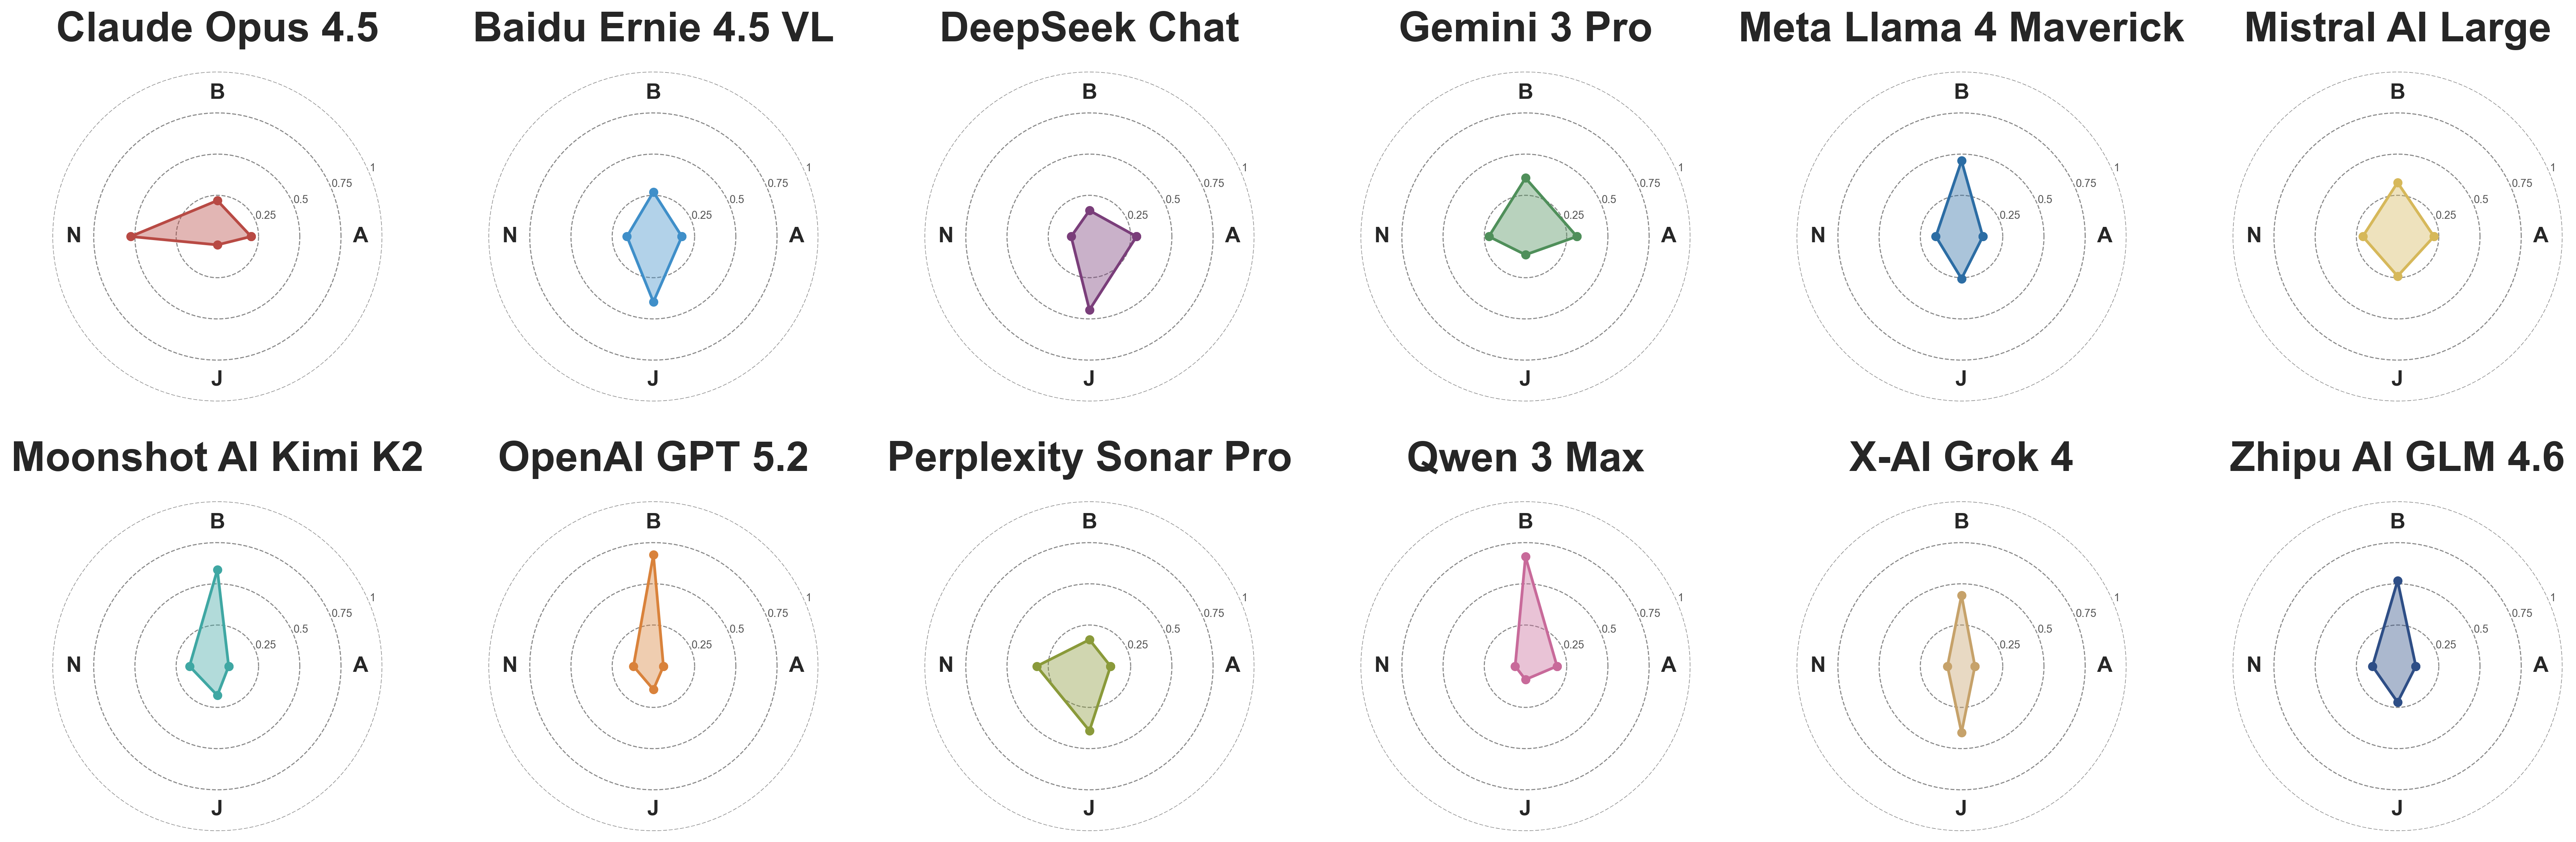

In [101]:
values_cap = [v.capitalize() for v in VALUE_NAMES]
num_vars = len(values_cap)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

llm_color_palette = [
    "#B84A44", "#3F8FC9", "#7A3E7A", "#4F8F5A",
    "#2C6DA4", "#D6B85A", "#3FA7A3", "#D9823B",
    "#8A9A3A", "#C86A9A", "#C6A26A", "#2E4E86",
]
human_consensus_color = "#1a1a1a"
human_participant_grey = "#888888"

def _color_for(model):
    if model == HUMAN_CONSENSUS:
        return human_consensus_color
    if model.startswith("human/"):
        return human_participant_grey
    idx = llm_models.index(model) if model in llm_models else 0
    return llm_color_palette[idx % len(llm_color_palette)]

models_to_plot =  llm_models # llm_models + [HUMAN_CONSENSUS] + human_participants
n = len(models_to_plot)
n_cols = 6
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 4 * n_rows),
                         subplot_kw=dict(polar=True))
axes = np.atleast_2d(axes).flatten()
theta_circle = np.linspace(0, 2 * np.pi, 100)
short_labels = ["A", "B", "N", "J"]

for i, model in enumerate(models_to_plot):
    ax = axes[i]
    pi = profiles[model]
    vals = [pi[v] for v in VALUE_NAMES] + [pi[VALUE_NAMES[0]]]
    color = _color_for(model)

    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1])
    ax.set_yticklabels(["0.25", "0.5", "0.75", "1"], fontsize=7, color="#555555")
    ax.yaxis.grid(False)
    ax.xaxis.grid(False, color="#aaaaaa", linewidth=0.5)

    for circle in [.25, 0.5, .75, 1]:
        ax.plot(theta_circle, [circle] * 100, color="#888888", lw=0.7, ls="--", zorder=1)

    ax.plot(angles, vals, marker="o", markersize=5, lw=1.8, color=color, zorder=3)
    ax.fill(angles, vals, alpha=0.4, color=color, zorder=2)

    ax.set_thetagrids(np.degrees(angles[:-1]), [""] * num_vars)
    for angle, label in zip(angles[:-1], short_labels):
        ax.text(angle, .87, label, fontsize=14, ha="center", va="center", fontweight="bold")

    ax.spines["polar"].set_visible(False)
    ax.set_title(get_display_name(model), fontsize=27, fontweight="bold", pad=20)

    ax.xaxis.grid(False)

for j in range(n, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout(rect=[0, 0.03, 1, 1], h_pad=3.0)
plt.show()

# physician consensus figsize 16 fontsize 14 pad 35 
# llm ncols 6 figsize 24 fontsize 27 pad 20 
# humans ncols 5 figsize 16 fontsize 22 pad 20 

## 5. Likelihood-ratio test for non-uniform prioritisation

H₀: the decision maker weighs all four values equally (uniform prior).
Rejecting H₀ (p < 0.05) means the profile is significantly non-uniform.

In [102]:
lrt_rows = []
for model in all_decision_makers:
    try:
        res = lrt_uniform_null(decisions, model)
        lrt_rows.append({
            "Decision Maker": model,
            "LRT χ²": res["lrt_statistic"],
            "p-value": res["p_value"],
            "df": res["df"],
            "Reject H₀ (α=.05)": res["p_value"] < 0.05,
        })
    except Exception as exc:
        print(f"  skip {get_display_name(model)}: {exc}")

lrt_df = pd.DataFrame(lrt_rows).sort_values("LRT χ²", ascending=False).reset_index(drop=True)

n_reject = lrt_df["Reject H₀ (α=.05)"].sum()
print(f"{n_reject} / {len(lrt_df)} decision makers reject the uniform null at α = 0.05\n")

lrt_df.style.format({"LRT χ²": "{:.2f}", "p-value": "{:.4f}"}).map(
    lambda v: "background-color: #d4edda" if v is True else "",
    subset=["Reject H₀ (α=.05)"],
)

nonuniform_decision_makers = lrt_df.query("`p-value` <= 0.05").get("Decision Maker").values.tolist()

21 / 33 decision makers reject the uniform null at α = 0.05



## 6. Pairwise Jensen-Shannon divergence matrix

JSD (divergence, not distance) between softmax(β / T) profiles.
Darker = more divergent value priorities.

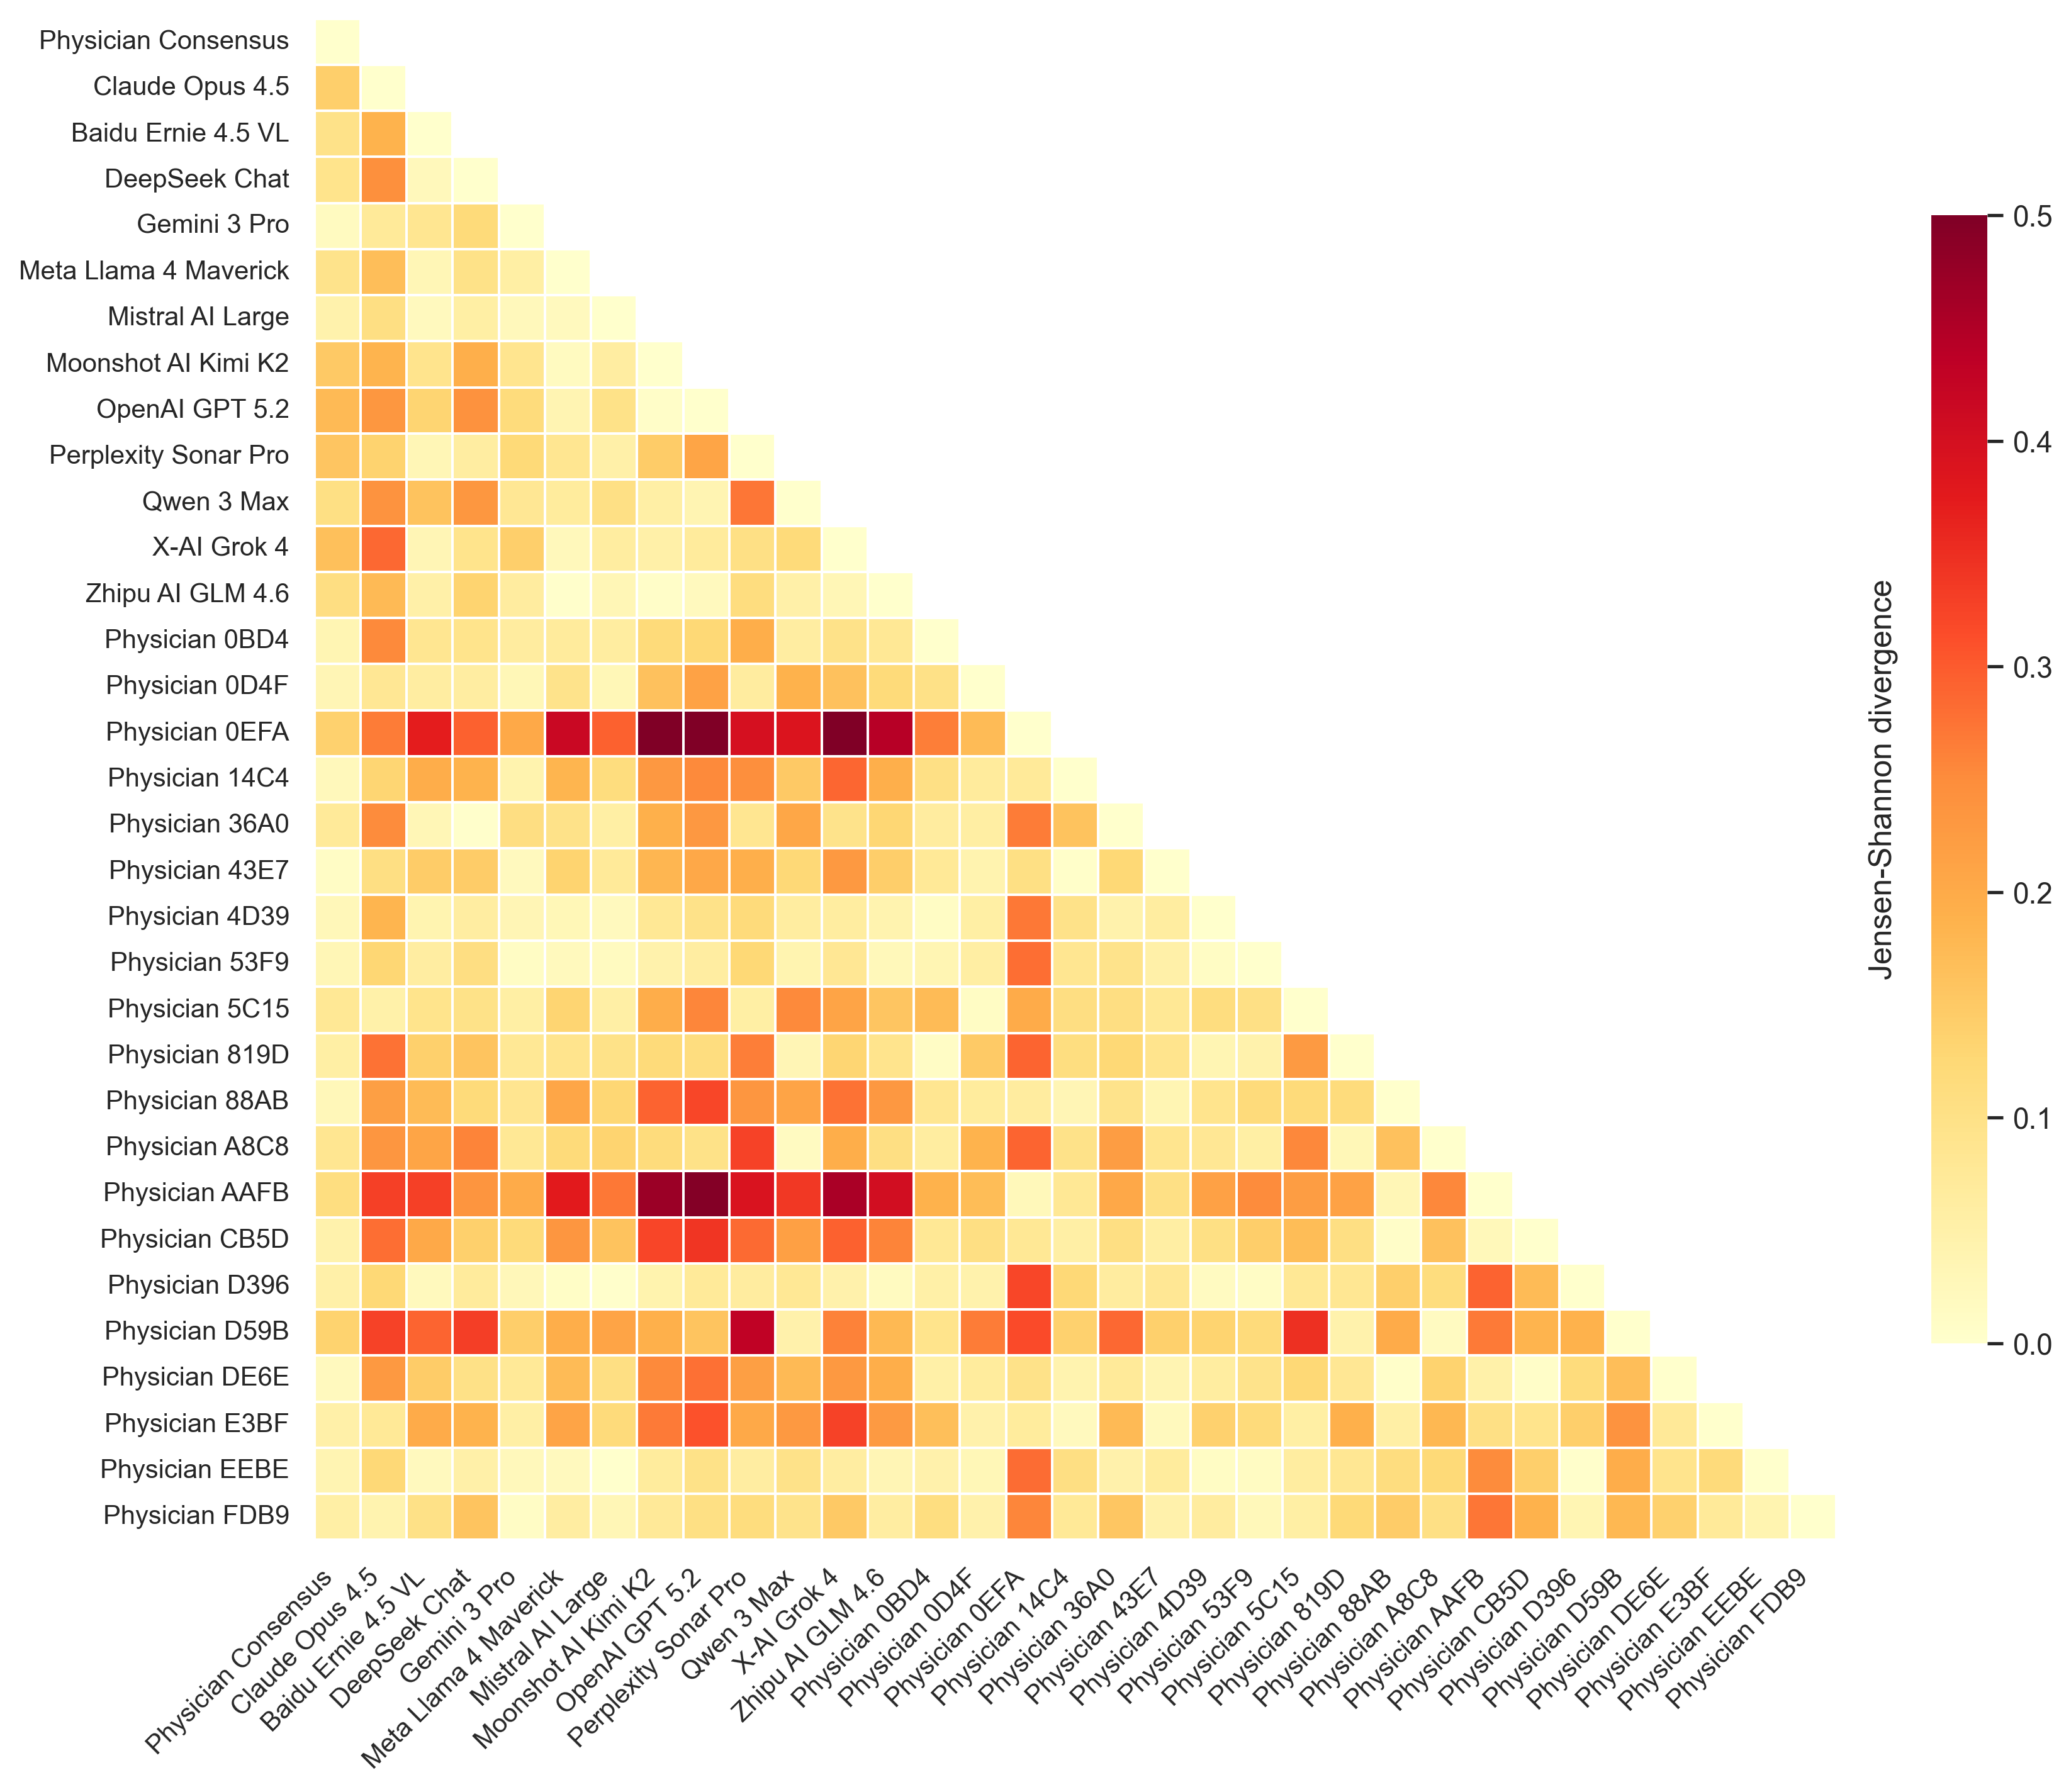

In [121]:
models_for_jsd = [HUMAN_CONSENSUS] + llm_models + human_participants
jsd_profiles = {m: profiles[m] for m in models_for_jsd}
jsd_mat = pairwise_jsd_matrix(jsd_profiles)

jsd_display = jsd_mat.copy()
jsd_display.index = [get_display_name(m) for m in jsd_display.index]
jsd_display.columns = [get_display_name(m) for m in jsd_display.columns]

mask = np.triu(np.ones_like(jsd_display, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(12, 10))
im = sns.heatmap(
    jsd_display,
    mask=mask,
    annot=False, fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    square=True,
    vmin=0, vmax=0.5,
    cbar_kws={"label": "Jensen-Shannon divergence", "shrink": 0.7},
    ax=ax,
)
cbar = im.collections[0].colorbar
cbar.set_label("Jensen-Shannon divergence", labelpad=-70)
ax.grid(False)
# ax.set_title("Pairwise JSD between LLM + Physician Consensus profiles", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

## 7. Distributional pluralism — within-group JSD

Compares how diverse value profiles are *within* LLMs versus
*within* physicians (individual participants). Higher mean JSD
implies greater value pluralism.

  LLMs                  mean = 0.0916   95% CI [0.0512, 0.1323]
  Physicians            mean = 0.1089   95% CI [0.0792, 0.1393]
  Δ (LLM − Phys)        mean = -0.0173   95% CI [-0.0679, 0.0327]


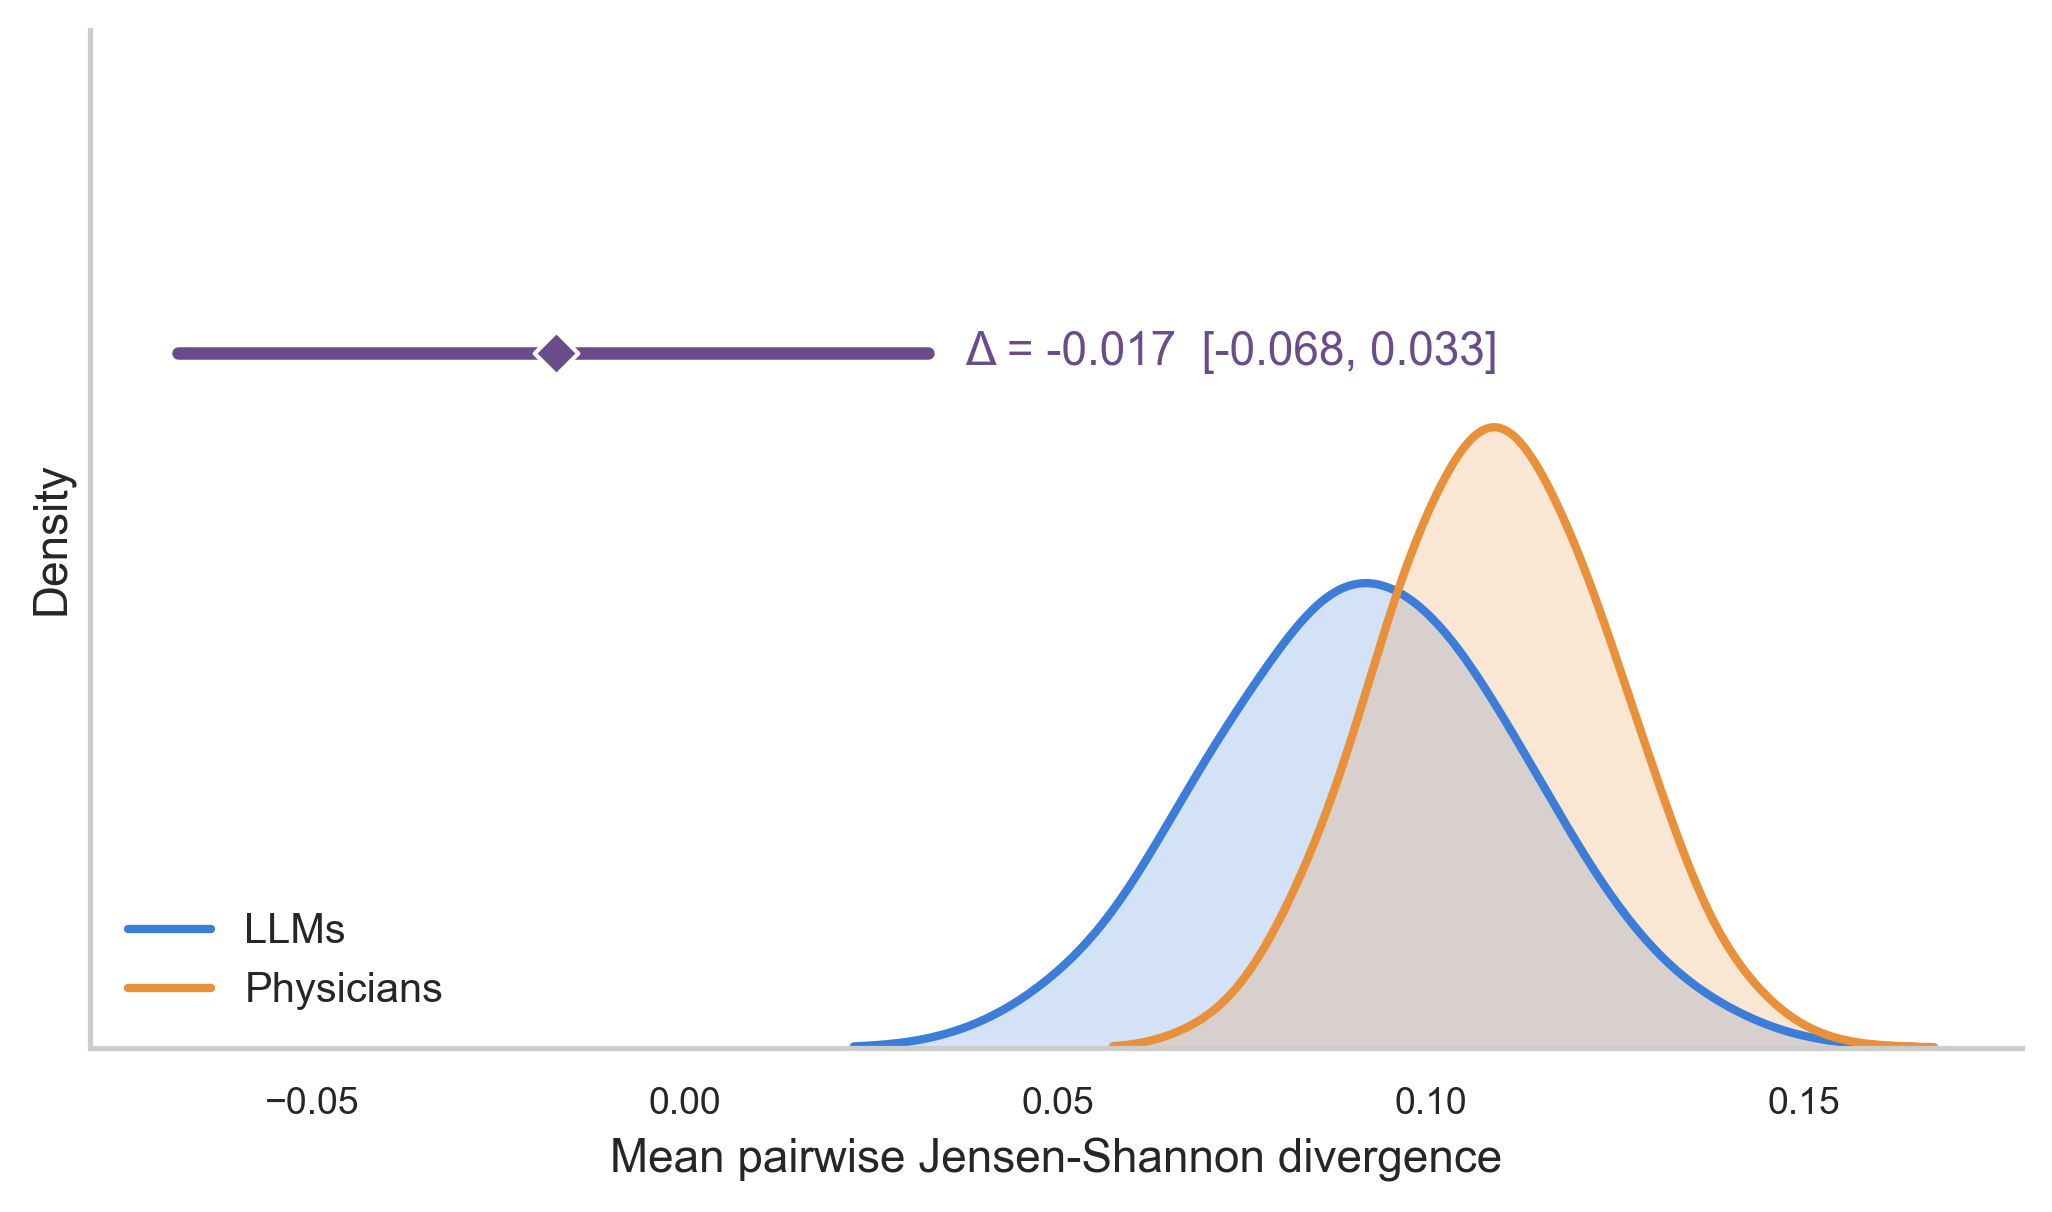

In [104]:
physician_profiles = {m: profiles[m] for m in human_participants if m in profiles}
llm_profiles = {m: profiles[m] for m in llm_models if m in profiles}

# OPTIONAL: only include decision makers that have non-uniform value profiles
# physician_profiles = {m: profiles[m] for m in physician_profiles if m in nonuniform_decision_makers}
# llm_profiles = {m: profiles[m] for m in llm_profiles if m in nonuniform_decision_makers}   

all_profiles_for_boot = {**llm_profiles, **physician_profiles}
llm_ids = list(llm_profiles.keys())
physician_ids = list(physician_profiles.keys())

boot = bootstrap_mean_jsd(
    all_profiles_for_boot,
    group_a_ids=llm_ids,
    group_b_ids=physician_ids,
    n_bootstrap=10_000,
    seed=42,
)

for label, key in [("LLMs", "group_a_mean"), ("Physicians", "group_b_mean"), ("Δ (LLM − Phys)", "difference")]:
    br = boot[key]
    lo, hi = br.ci(95)
    print(f"  {label:20s}  mean = {br.mean:.4f}   95% CI [{lo:.4f}, {hi:.4f}]")

from scipy.stats import gaussian_kde
import matplotlib.gridspec as gridspec

llm_br = boot["group_a_mean"]
phys_br = boot["group_b_mean"]
diff_br = boot["difference"]

llm_color = "#3B7DD8"
phys_color = "#E8913A"
diff_color = "#6B4C8A"

fig, ax = plt.subplots(figsize=(7, 4.2))

# ── KDE curves (normal, upright) ──
peak_y = 0
for br, color, label in [
    (llm_br, llm_color, "LLMs"),
    (phys_br, phys_color, "Physicians"),
]:
    kde = gaussian_kde(br.samples, bw_method=0.3)
    xs = np.linspace(br.samples.min(), br.samples.max(), 400)
    ys = kde(xs)
    peak_y = max(peak_y, ys.max())
    ax.fill_between(xs, ys, alpha=0.22, color=color)
    ax.plot(xs, ys, color=color, lw=2, label=label)
    # ax.axvline(br.mean, color=color, lw=1.3, ls="--", alpha=0.7)

# ── Δ CI bar above the density peaks ──
lo_d, hi_d = diff_br.ci(95)
bar_y = peak_y * 1.12

ax.plot([lo_d, hi_d], [bar_y, bar_y], color=diff_color, lw=3,
        solid_capstyle="round", zorder=4)
ax.scatter(diff_br.mean, bar_y, color=diff_color, s=55, zorder=5,
           edgecolors="white", linewidths=1.0, marker="D")
ax.text(hi_d + 0.002, bar_y,
        f"  Δ = {diff_br.mean:.3f}  [{lo_d:.3f}, {hi_d:.3f}]",
        va="center", ha="left", fontsize=11, color=diff_color,
        fontweight="medium")

ax.set_ylabel("Density", fontsize=11)
ax.set_xlabel("Mean pairwise Jensen-Shannon divergence", fontsize=11)
ax.legend(fontsize=10, frameon=False, fancybox=False, shadow=False,
          edgecolor="#cccccc", loc="lower left")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=9)
ax.set_yticks([])
ax.set_ylim(0, 40)
ax.grid(False)

plt.tight_layout()
plt.show()

## 8. Permutation test — are LLMs and physicians equally diverse?

H₀: the mean within-group JSD is the same for both populations.
Test statistic: |mean\_jsd(LLMs) − mean\_jsd(Physicians)|.

Observed |Δ|  = 0.0148
p-value       = 0.6814


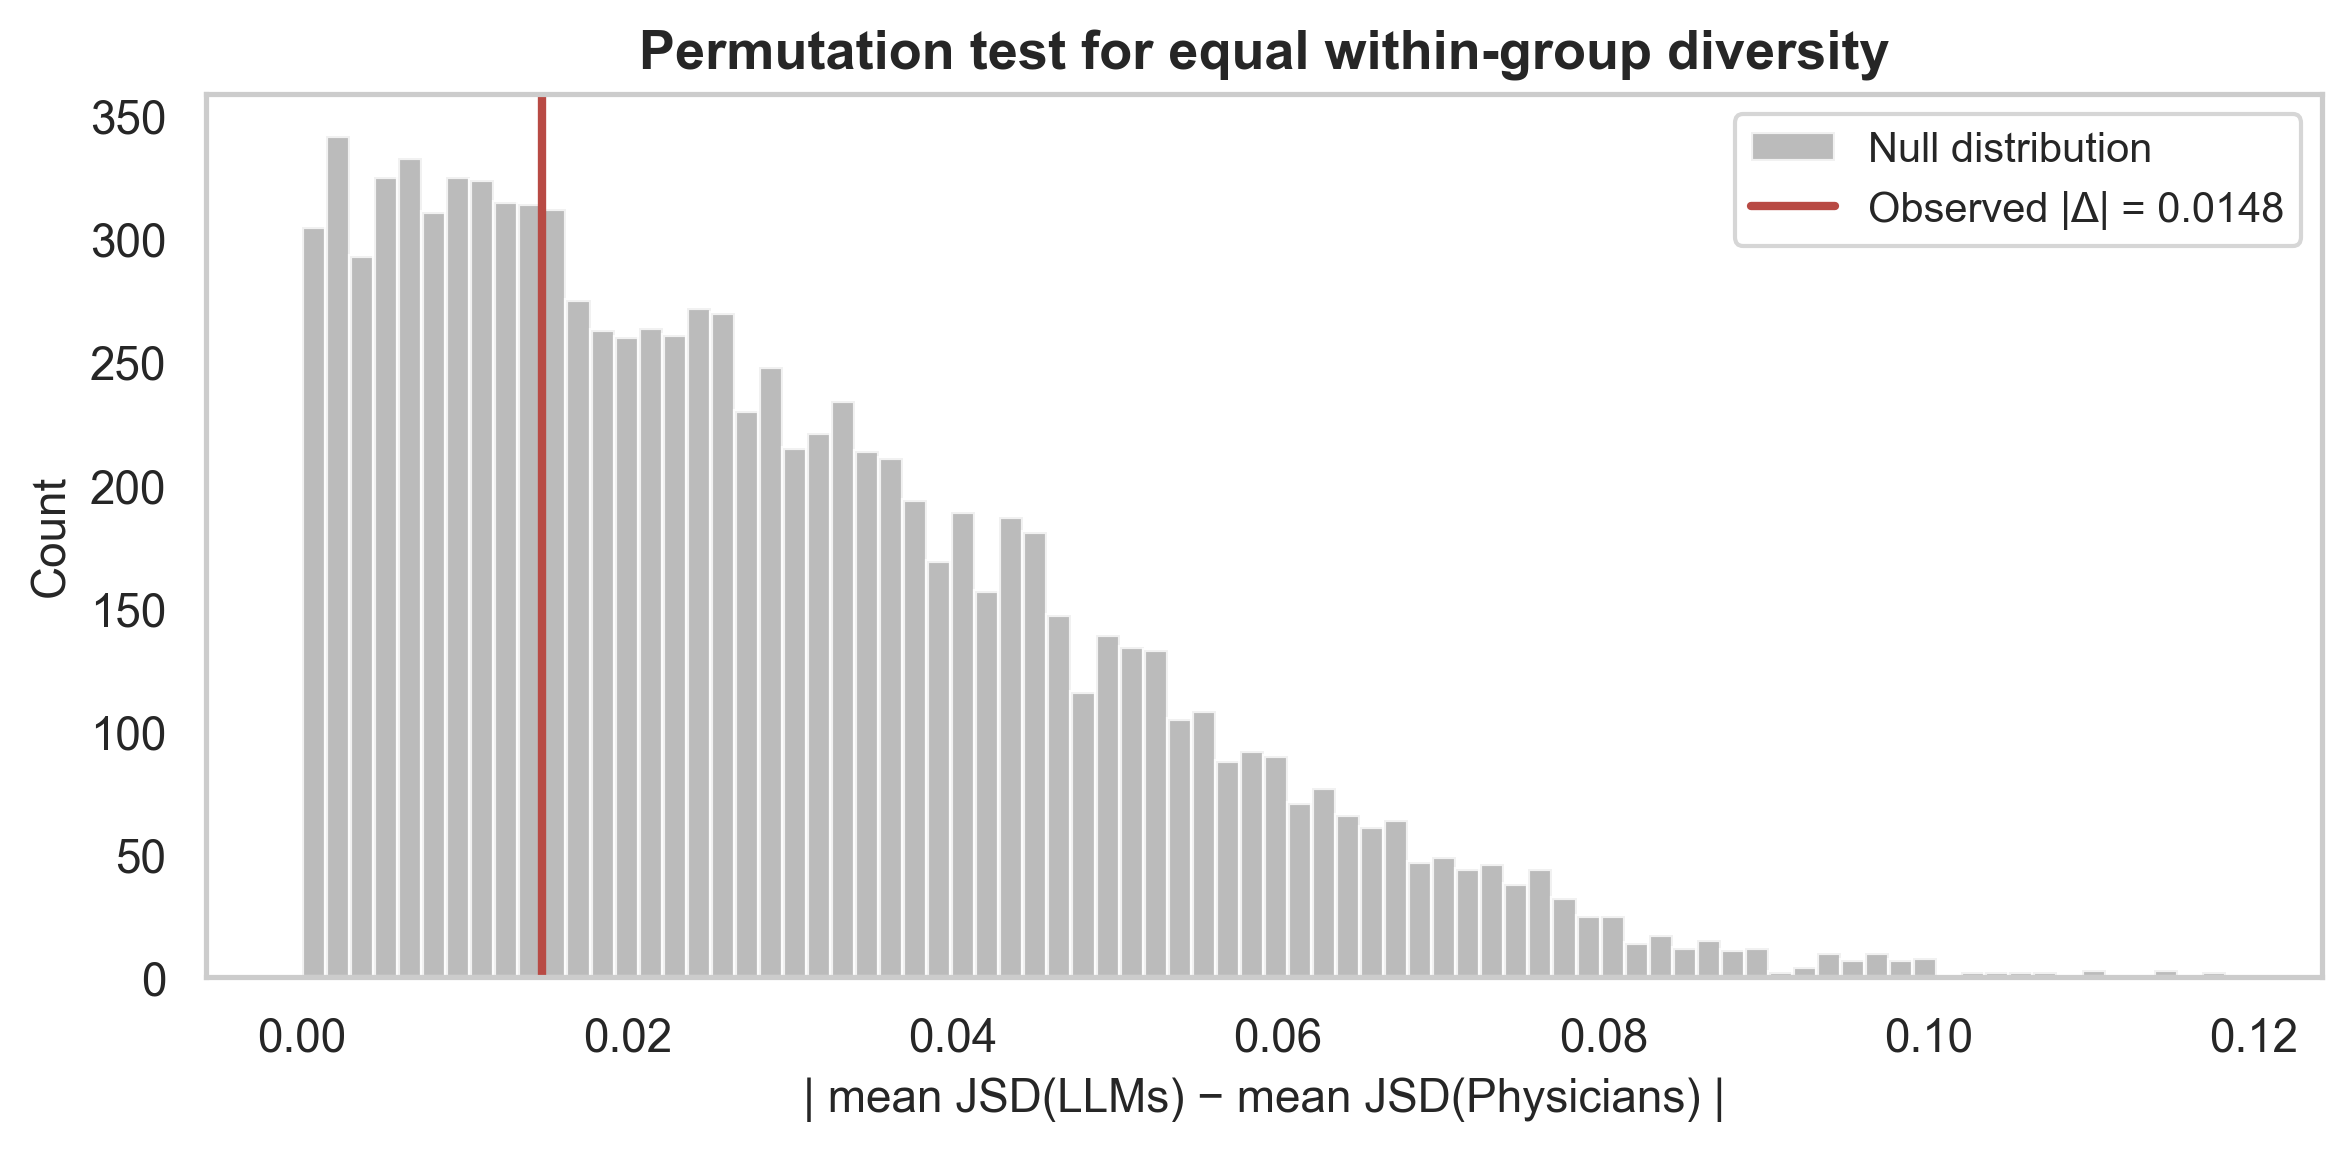


→ Cannot reject H₀ at α = 0.05: no significant difference in within-group diversity.


In [105]:
perm = permutation_test_jsd(
    all_profiles_for_boot,
    group_a_ids=llm_ids,
    group_b_ids=physician_ids,
    n_permutations=10_000,
    seed=42,
)

print(f"Observed |Δ|  = {perm['observed_diff']:.4f}")
print(f"p-value       = {perm['p_value']:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm["null_distribution"], bins=80, color="#aaaaaa", edgecolor="white", alpha=0.8, label="Null distribution")
ax.axvline(perm["observed_diff"], color="#B84A44", lw=2, ls="-", label=f"Observed |Δ| = {perm['observed_diff']:.4f}")
ax.set_xlabel("| mean JSD(LLMs) − mean JSD(Physicians) |", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Permutation test for equal within-group diversity", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(False)
plt.tight_layout()
plt.show()

if perm["p_value"] < 0.05:
    print(f"\n→ Reject H₀ at α = 0.05: the two groups differ significantly in value diversity.")
else:
    print(f"\n→ Cannot reject H₀ at α = 0.05: no significant difference in within-group diversity.")

## 9. Per-value distributional tests — LLMs vs Physicians

For each ethical value independently, test whether the softmax(β / T) weight
(π) differs in distribution between LLMs and physicians using both
a **Mann-Whitney U test** and a **permutation test** on the difference
in group means.

In [106]:
from scipy.stats import mannwhitneyu

value_display = {
    "autonomy": "Autonomy", "beneficence": "Beneficence",
    "nonmaleficence": "Nonmaleficence", "justice": "Justice",
}

llm_pi = {v: np.array([llm_profiles[m][v] for m in llm_ids]) for v in VALUE_NAMES}
phys_pi = {v: np.array([physician_profiles[m][v] for m in physician_ids]) for v in VALUE_NAMES}

n_perm = 10_000
rng_perm = np.random.default_rng(42)
per_value_rows = []

for v in VALUE_NAMES:
    x_llm, x_phys = llm_pi[v], phys_pi[v]

    u_stat, p_mw = mannwhitneyu(x_llm, x_phys, alternative="two-sided")

    obs_diff = float(x_llm.mean() - x_phys.mean())
    pooled = np.concatenate([x_llm, x_phys])
    n_l = len(x_llm)
    null = np.empty(n_perm)
    for i in range(n_perm):
        p = rng_perm.permutation(pooled)
        null[i] = p[:n_l].mean() - p[n_l:].mean()
    p_perm = float(np.mean(np.abs(null) >= np.abs(obs_diff)))

    per_value_rows.append({
        "Value": value_display[v],
        "LLM mean π": round(x_llm.mean(), 4),
        "Physician mean π": round(x_phys.mean(), 4),
        "Δ (LLM − Phys)": round(obs_diff, 4),
        "Mann-Whitney U": round(u_stat, 1),
        "MW p-value": round(p_mw, 4),
        "Perm p-value": round(p_perm, 4),
    })

per_value_df = pd.DataFrame(per_value_rows)

alpha = 0.05
n_tests = len(VALUE_NAMES)
bonferroni_alpha = alpha / n_tests

def _highlight_sig(val):
    try:
        v = float(val)
        if v < bonferroni_alpha:
            return "font-weight: bold; color: #B84A44"
        elif v < alpha:
            return "color: #D9823B"
    except (ValueError, TypeError):
        pass
    return ""

print(f"Significance thresholds:  α = {alpha}  |  Bonferroni-corrected α = {bonferroni_alpha}")
per_value_df.style.map(_highlight_sig, subset=["MW p-value", "Perm p-value"]).hide(axis="index")

Significance thresholds:  α = 0.05  |  Bonferroni-corrected α = 0.0125


Value,LLM mean π,Physician mean π,Δ (LLM − Phys),Mann-Whitney U,MW p-value,Perm p-value
Autonomy,0.163700,0.425900,-0.262200,13.000000,0.000000,0.000100
Beneficence,0.402100,0.297900,0.104200,157.000000,0.155400,0.106900
Nonmaleficence,0.191400,0.139600,0.051800,152.000000,0.220100,0.214000
Justice,0.242700,0.136600,0.106100,174.000000,0.037300,0.016300


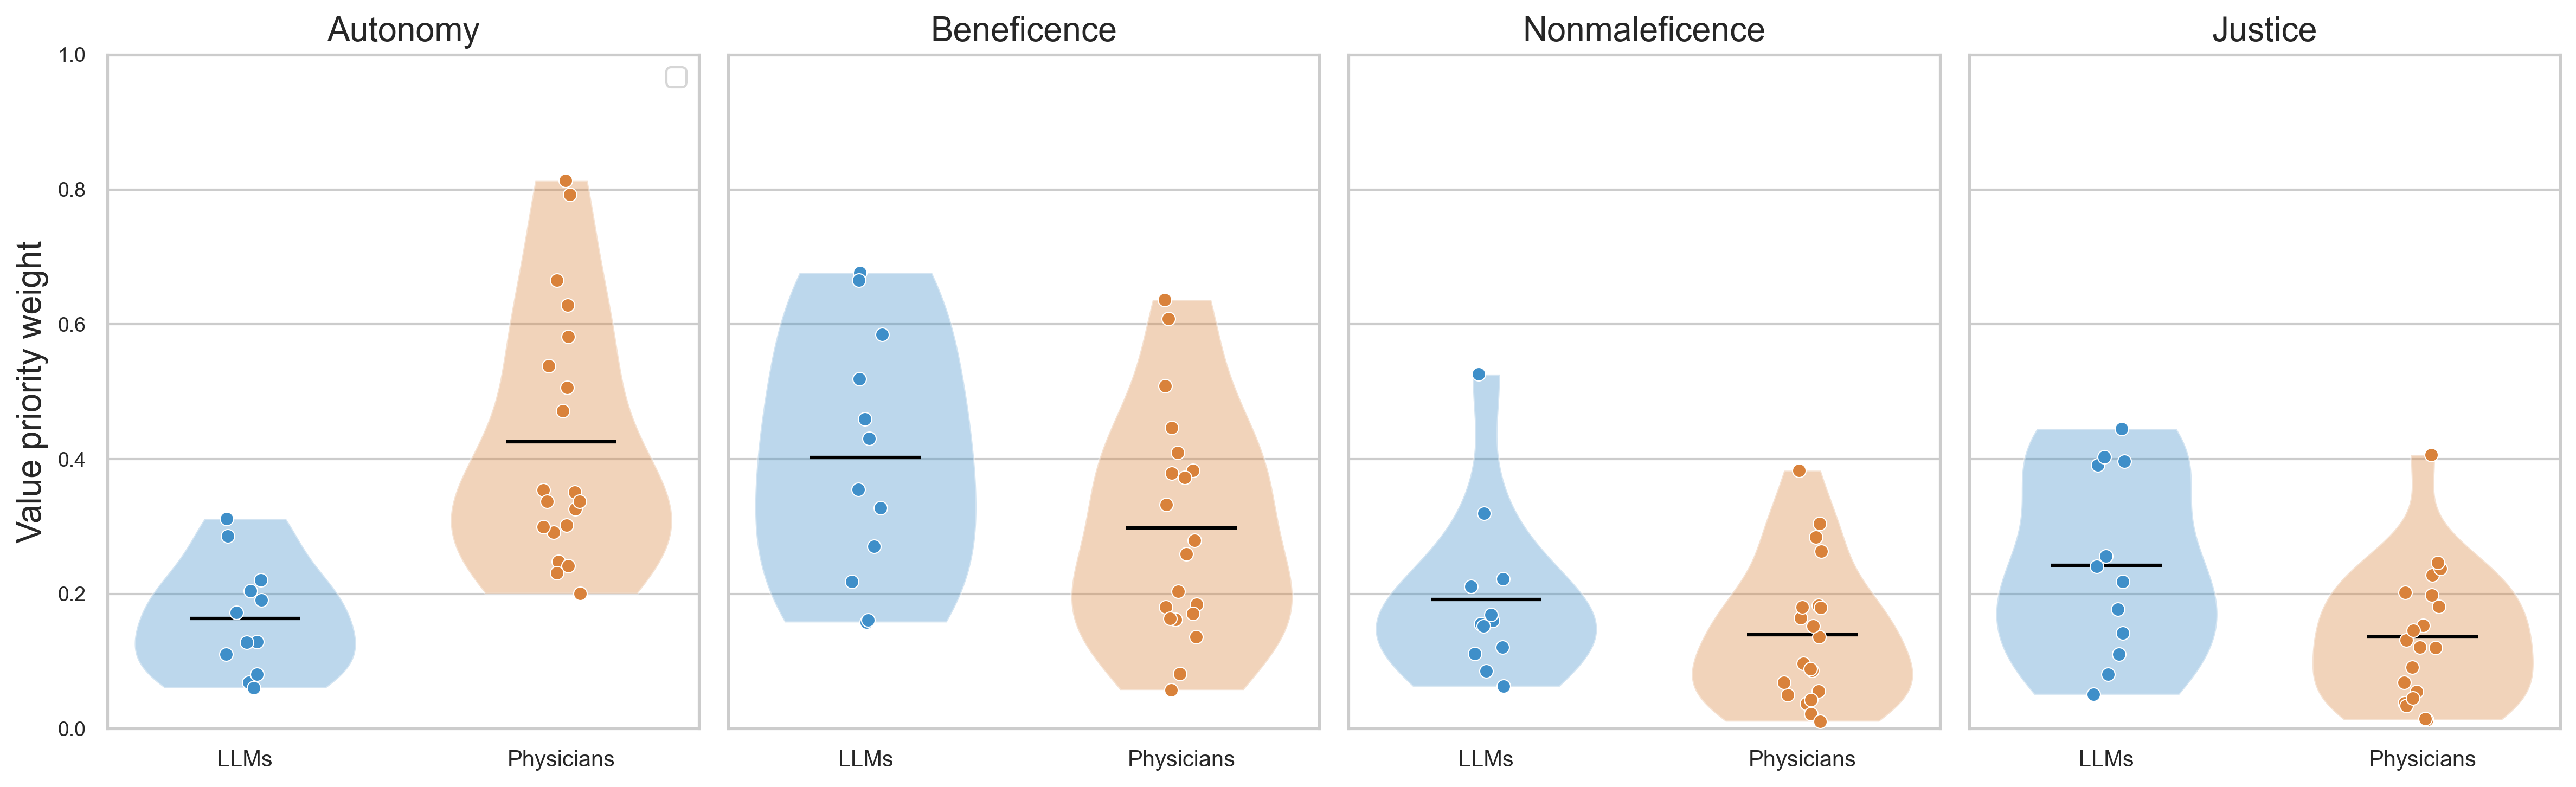


Interpretation (* p < 0.05, ** p < Bonferroni-corrected α):

  ** Autonomy: significant after Bonferroni correction (MW p=0.0000, Perm p=0.0001)
     Beneficence: no significant difference (MW p=0.1554, Perm p=0.1069)
     Nonmaleficence: no significant difference (MW p=0.2201, Perm p=0.2140)
   * Justice: nominally significant (MW p=0.0373, Perm p=0.0163)


In [107]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
rng_jit = np.random.default_rng(0)
group_colors = ["#3F8FC9", "#D9823B"]

for idx, v in enumerate(VALUE_NAMES):
    ax = axes[idx]
    x_llm, x_phys = llm_pi[v], phys_pi[v]

    parts = ax.violinplot(
        [x_llm, x_phys], positions=[0, 1],
        showmeans=True, showextrema=False, widths=0.7,
    )
    for pc, c in zip(parts["bodies"], group_colors):
        pc.set_facecolor(c)
        pc.set_alpha(0.35)
    parts["cmeans"].set_color("black")
    parts["cmeans"].set_linewidth(1.5)

    jitter = 0.06
    ax.scatter(
        rng_jit.uniform(-jitter, jitter, len(x_llm)), x_llm,
        c=group_colors[0], s=36, zorder=5,
        edgecolors="white", linewidths=0.5, label="LLMs",
    )
    ax.scatter(
        1 + rng_jit.uniform(-jitter, jitter, len(x_phys)), x_phys,
        c=group_colors[1], s=36, zorder=5,
        edgecolors="white", linewidths=0.5, label="Physicians",
    )

    row = per_value_rows[idx]
    sig = ""
    if row["MW p-value"] < bonferroni_alpha or row["Perm p-value"] < bonferroni_alpha:
        sig = " **"
    elif row["MW p-value"] < alpha or row["Perm p-value"] < alpha:
        sig = " *"

    ax.set_title(f"{value_display[v]}", fontsize=15)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["LLMs", "Physicians"], fontsize=10)
    if idx == 0:
        ax.set_ylabel(f"Value priority weight", fontsize=15)
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis='x')

axes[0].legend([])
plt.ylim(0,1)
plt.tight_layout()
plt.show()

print("\nInterpretation (* p < 0.05, ** p < Bonferroni-corrected α):\n")
for r in per_value_rows:
    mw_p, pm_p = r["MW p-value"], r["Perm p-value"]
    name = r["Value"]
    if mw_p < bonferroni_alpha or pm_p < bonferroni_alpha:
        print(f"  ** {name}: significant after Bonferroni correction "
              f"(MW p={mw_p:.4f}, Perm p={pm_p:.4f})")
    elif mw_p < alpha or pm_p < alpha:
        print(f"   * {name}: nominally significant "
              f"(MW p={mw_p:.4f}, Perm p={pm_p:.4f})")
    else:
        print(f"     {name}: no significant difference "
              f"(MW p={mw_p:.4f}, Perm p={pm_p:.4f})")

## 10. Consensus calibration — model distance to physician consensus

For every decision maker (12 LLMs + 20 individual physicians), measure how
far its value profile π is from the physician-consensus profile using
Jensen-Shannon divergence (squared, base 2).

In [ ]:
observed_jsd = {}
for dm in llm_models + human_participants:
    observed_jsd[dm] = jsd_mat.loc[dm, HUMAN_CONSENSUS]

print("Observed JSD to physician consensus (squared, base 2):\n")
for dm in sorted(observed_jsd, key=observed_jsd.get):
    tag = "LLM" if dm in llm_models else "Physician"
    print(f"  {get_display_name(dm):30s}  {observed_jsd[dm]:.4f}  ({tag})")

Observed JSD to physician consensus (squared, base 2):

  Physician 43E7                  0.0104  (Physician)
  Gemini 3 Pro                    0.0195  (LLM)
  Physician DE6E                  0.0201  (Physician)
  Physician 14C4                  0.0249  (Physician)
  Physician 4D39                  0.0274  (Physician)
  Physician 88AB                  0.0284  (Physician)
  Physician 53F9                  0.0331  (Physician)
  Physician 0D4F                  0.0334  (Physician)
  Physician 0BD4                  0.0369  (Physician)
  Physician EEBE                  0.0380  (Physician)
  Physician CB5D                  0.0453  (Physician)
  Mistral AI Large                0.0465  (LLM)
  Physician E3BF                  0.0511  (Physician)
  Physician D396                  0.0521  (Physician)
  Physician FDB9                  0.0559  (Physician)
  Physician 819D                  0.0581  (Physician)
  Physician 36A0                  0.0726  (Physician)
  Physician 5C15                  0.08

In [ ]:
B = 10000
SEED = 42
rng = np.random.default_rng(SEED)

physician_ref_jsds: list[float] = []
model_boot_jsds: dict[str, list[float]] = defaultdict(list)

for b in range(B):
    panel = list(rng.choice(human_participants, size=20, replace=True))

    for pos, physician in enumerate(panel):
        loo_panel = [p for i, p in enumerate(panel) if p != physician]
        loo_consensus = consensus_profile_from_subset(
            decisions, loo_panel, temperature=TEMPERATURE,
        )
        loo_vec = np.array([loo_consensus[v] for v in VALUE_NAMES])
        phys_vec = np.array([profiles[physician][v] for v in VALUE_NAMES])
        physician_ref_jsds.append(
            jensenshannon(phys_vec, loo_vec, base=2.0) ** 2
        )

    full_consensus = consensus_profile_from_subset(
        decisions, panel, temperature=TEMPERATURE,
    )
    full_vec = np.array([full_consensus[v] for v in VALUE_NAMES])
    for model in llm_models:
        model_vec = np.array([profiles[model][v] for v in VALUE_NAMES])
        model_boot_jsds[model].append(
            jensenshannon(model_vec, full_vec, base=2.0) ** 2
        )

physician_ref_jsds = np.array(physician_ref_jsds)
model_boot_jsds = {m: np.array(v) for m, v in model_boot_jsds.items()}

print(f"Physician reference distribution: {len(physician_ref_jsds)} values "
      f"(mean={physician_ref_jsds.mean():.4f}, "
      f"median={np.median(physician_ref_jsds):.4f})")
print(f"Model bootstrap arrays: {len(model_boot_jsds)} models × "
      f"{B} iterations each")

Physician reference distribution: 200000 values (mean=0.0642, median=0.0535)
Model bootstrap arrays: 12 models × 10000 iterations each


In [ ]:
calibration_rows = []
for model in llm_models:
    obs = observed_jsd[model]
    p_value = np.mean(physician_ref_jsds >= obs)
    ci_lo, ci_hi = np.percentile(model_boot_jsds[model], [2.5, 97.5])
    calibration_rows.append({
        "Model": get_display_name(model),
        "Observed JSD": obs,
        "CI 2.5%": ci_lo,
        "CI 97.5%": ci_hi,
        "p-value": p_value,
    })

calibration_rows.sort(key=lambda r: r["Observed JSD"])

print(f"{'Model':30s}  {'Obs JSD':>8s}  {'95% CI':>17s}  {'p-value':>8s}")
print("-" * 70)
for r in calibration_rows:
    ci_str = f"[{r['CI 2.5%']:.4f}, {r['CI 97.5%']:.4f}]"
    print(f"{r['Model']:30s}  {r['Observed JSD']:8.4f}  {ci_str:>17s}  {r['p-value']:8.4f}")

Model                            Obs JSD             95% CI   p-value
----------------------------------------------------------------------
Gemini 3 Pro                      0.0195   [0.0104, 0.0352]    0.9265
Mistral AI Large                  0.0465   [0.0285, 0.0721]    0.5831
DeepSeek Chat                     0.0928   [0.0722, 0.1177]    0.2022
Meta Llama 4 Maverick             0.0948   [0.0660, 0.1301]    0.1928
Baidu Ernie 4.5 VL                0.0962   [0.0700, 0.1278]    0.1871
Qwen 3 Max                        0.1045   [0.0763, 0.1389]    0.1602
Zhipu AI GLM 4.6                  0.1088   [0.0775, 0.1465]    0.1496
Claude Opus 4.5                   0.1407   [0.1136, 0.1708]    0.0778
Moonshot AI Kimi K2               0.1508   [0.1149, 0.1927]    0.0496
Perplexity Sonar Pro              0.1581   [0.1256, 0.1971]    0.0320
X-AI Grok 4                       0.1649   [0.1275, 0.2073]    0.0200
OpenAI GPT 5.2                    0.1752   [0.1365, 0.2190]    0.0086


In [ ]:
cal_df = pd.DataFrame(calibration_rows)
cal_df["95% CI"] = cal_df.apply(
    lambda r: f"[{r['CI 2.5%']:.4f}, {r['CI 97.5%']:.4f}]", axis=1,
)
cal_df = cal_df.drop(columns=["CI 2.5%", "CI 97.5%"])[
    ["Model", "Observed JSD", "95% CI", "p-value"]
]

def _highlight_cal_p(val):
    try:
        v = float(val)
    except (TypeError, ValueError):
        return ""
    if v < 0.05:
        return "background-color: #f8d7da"
    return "background-color: #d4edda"

cal_df.style.format(
    {"Observed JSD": "{:.4f}", "p-value": "{:.4f}"}
).map(_highlight_cal_p, subset=["p-value"]).hide(axis="index")

Model,Observed JSD,95% CI,p-value
Gemini 3 Pro,0.0195,"[0.0104, 0.0352]",0.9265
Mistral AI Large,0.0465,"[0.0285, 0.0721]",0.5831
DeepSeek Chat,0.0928,"[0.0722, 0.1177]",0.2022
Meta Llama 4 Maverick,0.0948,"[0.0660, 0.1301]",0.1928
Baidu Ernie 4.5 VL,0.0962,"[0.0700, 0.1278]",0.1871
Qwen 3 Max,0.1045,"[0.0763, 0.1389]",0.1602
Zhipu AI GLM 4.6,0.1088,"[0.0775, 0.1465]",0.1496
Claude Opus 4.5,0.1407,"[0.1136, 0.1708]",0.0778
Moonshot AI Kimi K2,0.1508,"[0.1149, 0.1927]",0.0496
Perplexity Sonar Pro,0.1581,"[0.1256, 0.1971]",0.0320


0.15059442767361386


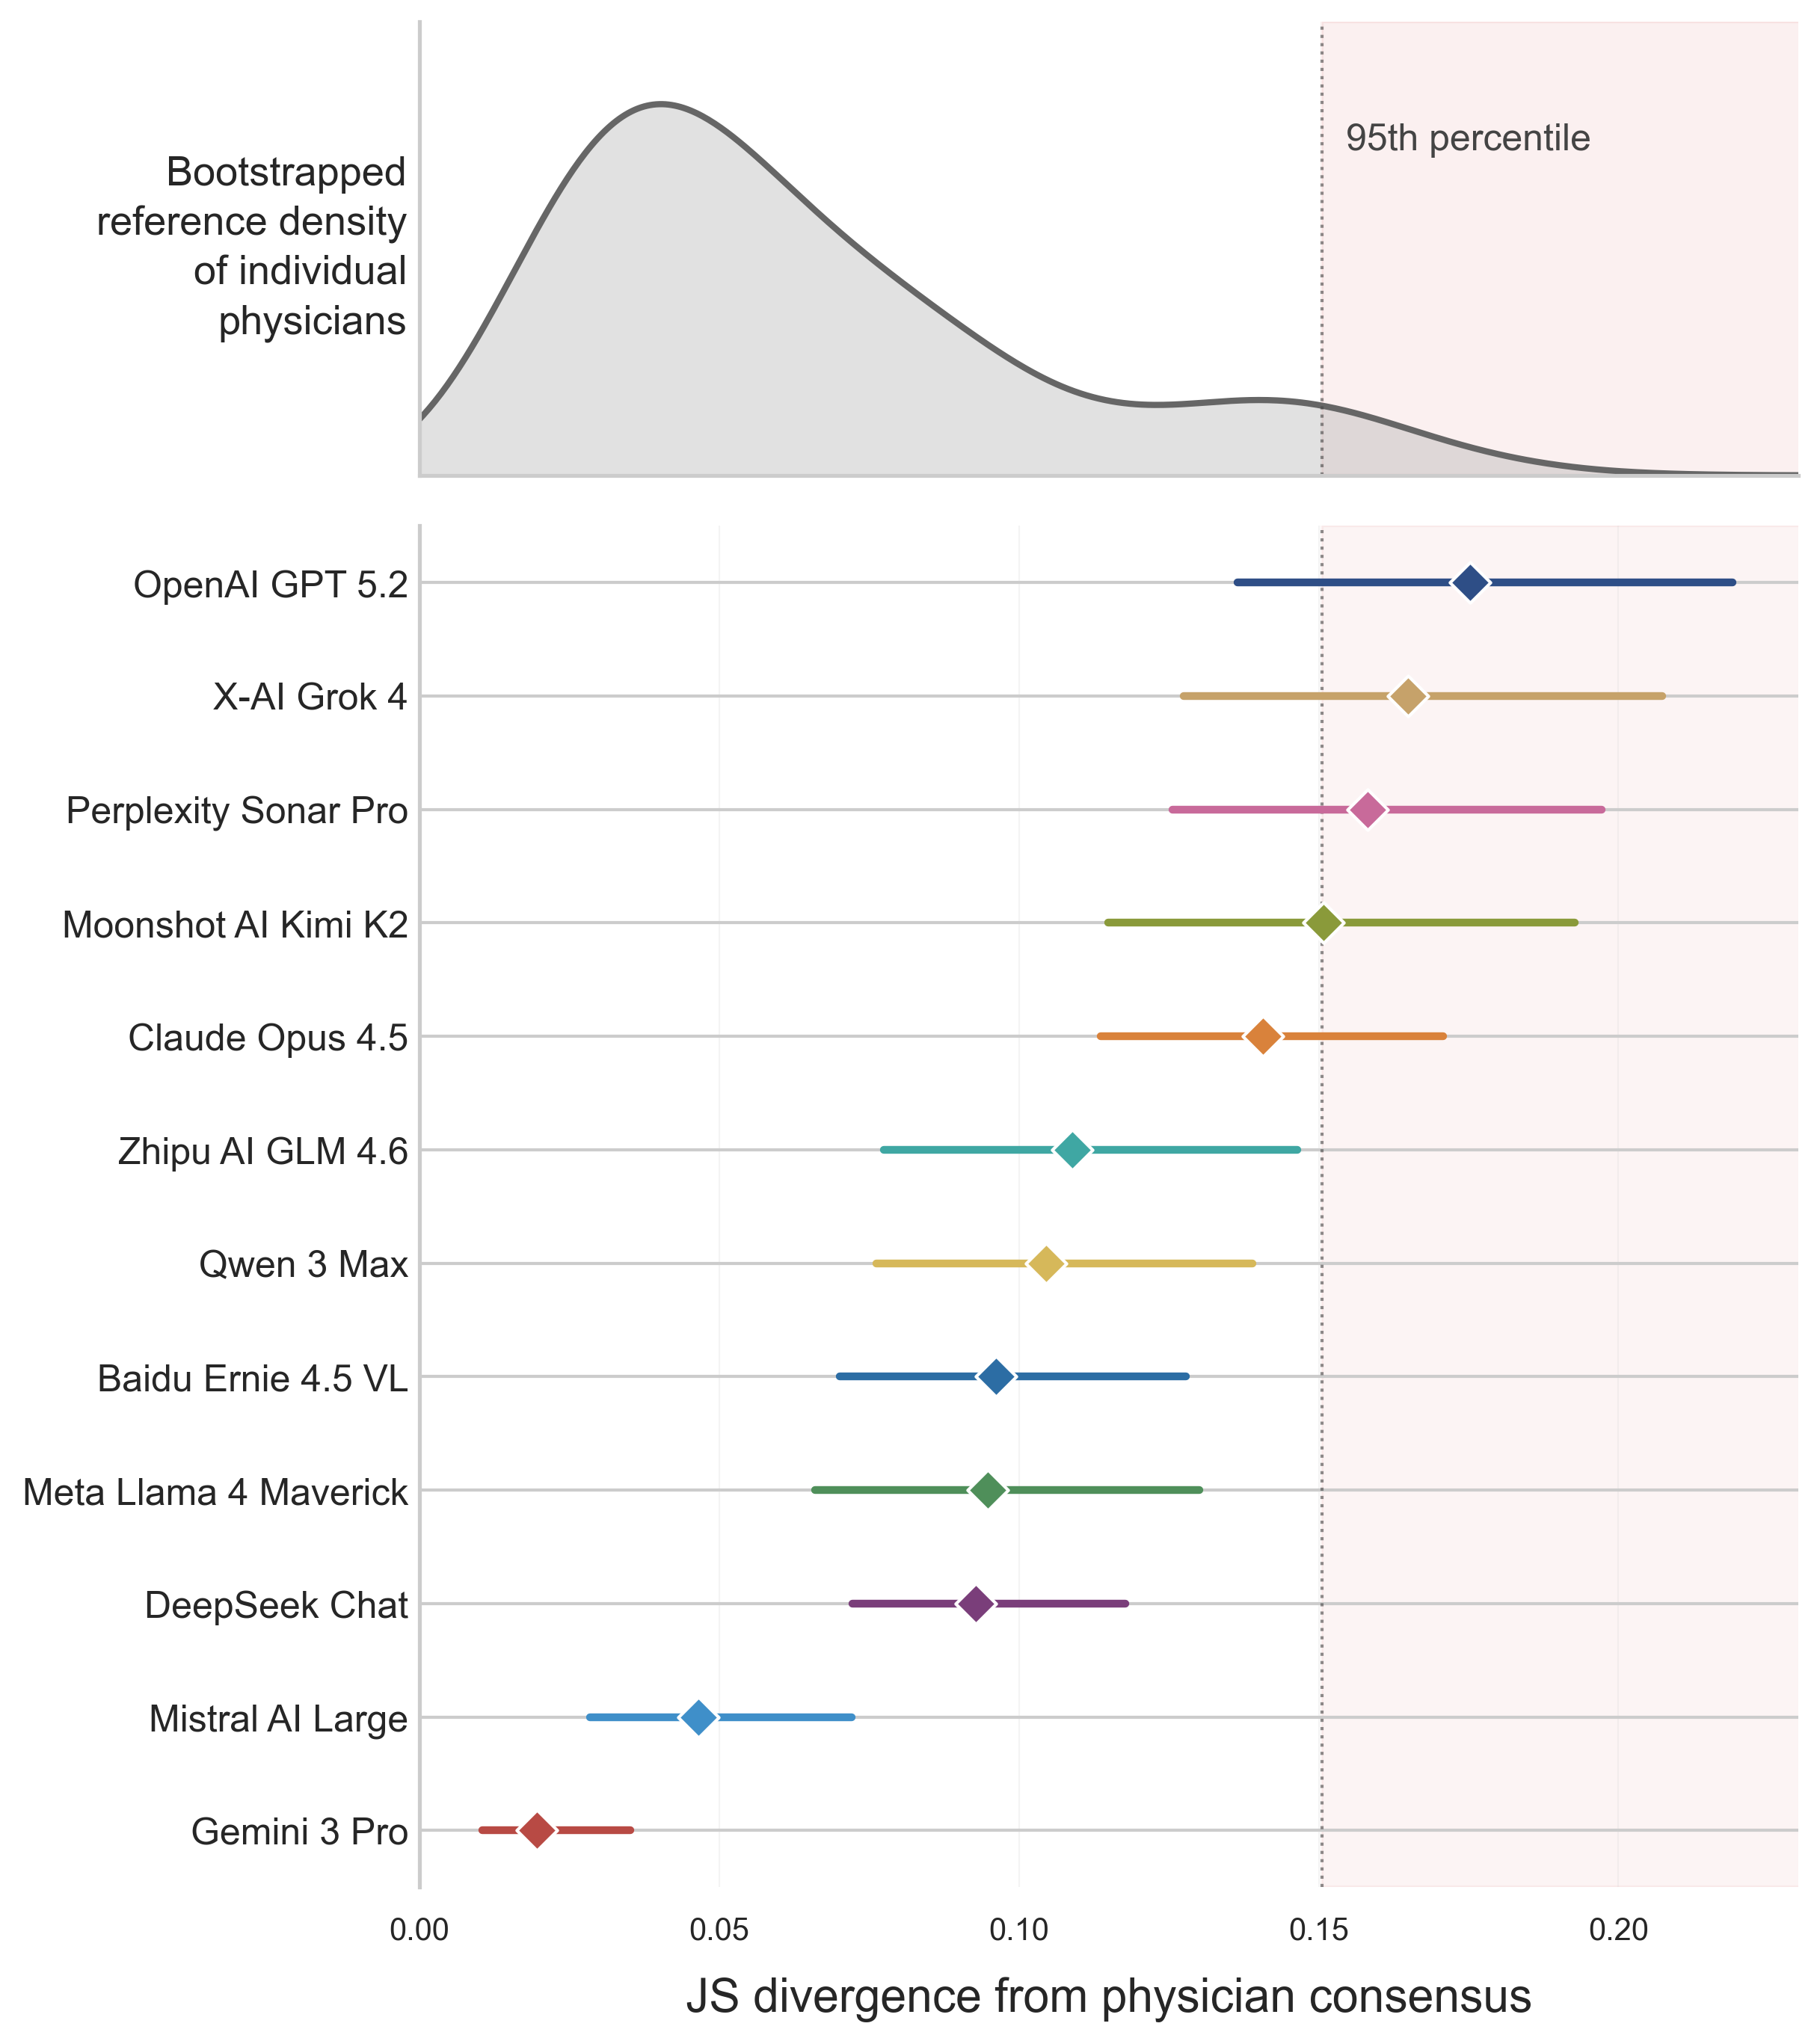

In [ ]:
from scipy.stats import gaussian_kde as _kde_fn
from matplotlib.lines import Line2D

sorted_models = sorted(llm_models, key=lambda m: observed_jsd[m])
n_models = len(sorted_models)
model_colors = llm_color_palette

fig, (ax_kde, ax_forest) = plt.subplots(
    2, 1, figsize=(8, 9), sharex=True,
    gridspec_kw={"height_ratios": [1, 3], "hspace": 0.05},
    layout="constrained",
)

# ── Top panel: KDE of physician reference distribution ──
kde = _kde_fn(physician_ref_jsds, bw_method=0.3)
x_hi = max(physician_ref_jsds.max(), max(observed_jsd[m] for m in llm_models)) + 0.02
xs = np.linspace(0, x_hi, 500)
ys = kde(xs)

ax_kde.fill_between(xs, ys, alpha=0.35, color="#aaaaaa")
ax_kde.plot(xs, ys, color="#666666", lw=2, label="Physician LOO reference")

p95 = np.percentile(physician_ref_jsds, 95)
ax_kde.axvspan(p95, x_hi, alpha=0.08, color="#cc4444", zorder=0)
ax_kde.axvline(p95, color="#444444", lw=1, ls=":", alpha=0.6)
ax_kde.text(p95 + 0.004, ys.max() * 0.95, "95th percentile",
            fontsize=12, color="#444444", va="top")

ax_kde.set_yticks([])
ax_kde.set_ylabel("Bootstrapped\nreference density\nof individual\nphysicians",
                   fontsize=13, rotation=0,
                   linespacing=1.4, va="center", ha="right")
ax_kde.spines[["top", "right"]].set_visible(False)
# ax_kde.legend(fontsize=10, frameon=False, loc="upper right")
ax_kde.grid(False)
ax_kde.set_xlim(0,0.2)
ax_kde.set_ylim(0,15)

# ── Bottom panel: forest plot (observed JSD + 95% bootstrap CI) ──
ax_forest.axvspan(p95, x_hi, alpha=0.06, color="#cc4444", zorder=0)

for i, model in enumerate(sorted_models):
    obs = observed_jsd[model]
    ci_lo, ci_hi = np.percentile(model_boot_jsds[model], [2.5, 97.5])
    color = model_colors[i]

    ax_forest.plot(
        [ci_lo, ci_hi], [i, i], color=color, lw=2.5,
        solid_capstyle="round", zorder=3,
    )
    ax_forest.scatter(
        obs, i, color=color, s=85, zorder=5,
        edgecolors="white", linewidths=1.0, marker="D",
    )

ax_forest.axvline(p95, color="#444444", lw=1, ls=":", alpha=0.6)

ax_forest.set_yticks(range(n_models))
ax_forest.set_yticklabels(
    [get_display_name(m) for m in sorted_models], fontsize=12, 
)
ax_forest.set_xlabel(
    "JS divergence from physician consensus", fontsize=15, labelpad=10
)
ax_forest.spines[["top", "right", "bottom"]].set_visible(False)
ax_forest.set_ylim(-0.5, n_models - 0.5)
ax_forest.grid(axis="x", alpha=0.2, lw=0.5)
ax_forest.set_axisbelow(True)
ax_forest.tick_params(axis="y", length=0)
ax_forest.tick_params(axis="x", labelsize=10)
ax_forest.set_xticks([0,0.05,0.1,0.15,0.2])

plt.xlim(0,0.23)
plt.show()